# 1. Project Overview

### Goal
This project analyzes NYC Taxi data to identify actionable, data-driven strategies for reducing traffic congestion.

### Problem
NYC's transit system faces significant congestion, particularly in Manhattan. Not only does this waste people's time, it also increases carbon emissions and accidents. This analysis explores how shifts in transportation modes, pricing, and technology can alleviate these issues.

### Methodology
1. **Data Exploration**: Analyzing hundreds of thousands of trip records to find patterns in distance, speed, and time of day.
2. **Inefficient Zone Mapping**: Identifying the specific zones and routes that act as bottlenecks.
3. **Policy Simulation**: Modeling the impact of dynamic congestion surcharges and carpooling.
# Table of Contents

1. Project Overview
2. Loading the Data
3. Cleaning the Data
4. Initial Analysis
5. Trip Distance Optimization
6. Congestion vs. Time of Day
7. Dynamic Pricing Simulation
8. Inefficient Zone Mapping
9. Carpooling Simulation
10. Summary

# 2. Loading the Data

In [ ]:
import pandas as pd

file_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"

print("Fetching data...")

df = pd.read_parquet(file_url)

print("Data Shape: ", df.shape)
print(df.info())
print(df.head())

Fetching data...
Data Shape:  (2964624, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2964624 entries, 0 to 2964623
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge 

The data set is too large to process fully containing almost 3 million rows so we use a Bernoulli sample to get approximately 1% of the data and we do this for each month of 2024 (Dec 2025 isn't available so we use 2024).


In [ ]:
import numpy as np
import pandas as pd

monthly_samples = []
np.random.seed(23) # random seed for reproducibility

for month in range(1, 13):
    month_str = str(month).zfill(2)
    file_url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-{month_str}.parquet"

    print(f"Fetching and sampling data for {file_url}...")

    try:
        df_monthly = pd.read_parquet(file_url)

        # Apply a 1% Bernoulli sample since dataset too large
        boolean_series_monthly = np.random.rand(len(df_monthly)) < 0.01
        df_sample_monthly = df_monthly[boolean_series_monthly]

        monthly_samples.append(df_sample_monthly)
        print(f"Sampled {len(df_sample_monthly)} rows from {file_url}")
    except Exception:
        print(f"Error processing {file_url}: {Exception}")

# Concatenate all monthly samples into a single DataFrame
combined_df_sample = pd.concat(monthly_samples, ignore_index=True)

print(f"\nShape of combined_df_sample: {combined_df_sample.shape}")
print("First 5 rows of combined_df_sample:")
print(combined_df_sample.head())

Fetching and sampling data for https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet...
Sampled 29674 rows from https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet
Fetching and sampling data for https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-02.parquet...
Sampled 30013 rows from https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-02.parquet
Fetching and sampling data for https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-03.parquet...
Sampled 35603 rows from https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-03.parquet
Fetching and sampling data for https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-04.parquet...
Sampled 35196 rows from https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-04.parquet
Fetching and sampling data for https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-05.parquet...
Sampled 37558 

# 3. Cleaning the Data

The dataset contains many bad values that need to be filtered out such as having negative trip distance or 0 passengers.



In [ ]:
print(f"Initial shape of combined_df_sample: {combined_df_sample.shape}")

current_shape = combined_df_sample.shape[0]

# Check passenger count condition
filtered_df = combined_df_sample[combined_df_sample['passenger_count'] >= 1]
rows_removed_passenger = current_shape - filtered_df.shape[0]
print(f"Rows removed by 'passenger_count >= 1': {rows_removed_passenger}")
current_shape = filtered_df.shape[0]
combined_df_sample = filtered_df.copy()

# Check trip distance condition
filtered_df = combined_df_sample[combined_df_sample['trip_distance'] > 0]
rows_removed_trip_distance = current_shape - filtered_df.shape[0]
print(f"Rows removed by 'trip_distance > 0': {rows_removed_trip_distance}")
current_shape = filtered_df.shape[0]
combined_df_sample = filtered_df.copy()

# Check total amount condition
filtered_df = combined_df_sample[combined_df_sample['total_amount'] > 0]
rows_removed_total_amount = current_shape - filtered_df.shape[0]
print(f"Rows removed by 'total_amount > 0': {rows_removed_total_amount}")
current_shape = filtered_df.shape[0]
combined_df_sample = filtered_df.copy()

# Check dropoff time after pickup time condition
filtered_df = combined_df_sample[combined_df_sample['tpep_dropoff_datetime'] > combined_df_sample['tpep_pickup_datetime']]
rows_removed_date_check = current_shape - filtered_df.shape[0]
print(f"Rows removed by 'dropoff_datetime > pickup_datetime': {rows_removed_date_check}")
current_shape = filtered_df.shape[0]
combined_df_sample = filtered_df.copy()

print(f"Final shape after step-by-step cleaning: {combined_df_sample.shape}")

Initial shape of combined_df_sample: (412452, 19)
Rows removed by 'passenger_count >= 1': 45254
Rows removed by 'trip_distance > 0': 4917
Rows removed by 'total_amount > 0': 5556
Rows removed by 'dropoff_datetime > pickup_datetime': 16
Final shape after step-by-step cleaning: (356709, 19)


We check for missing values in case we need to do more data cleaning

In [ ]:
print("Missing values per column after initial cleaning:")
print(combined_df_sample.isnull().sum())

Missing values per column after initial cleaning:
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
Airport_fee              0
dtype: int64


# 4. Initial Analysis


We look at box plots and some summary statistics.

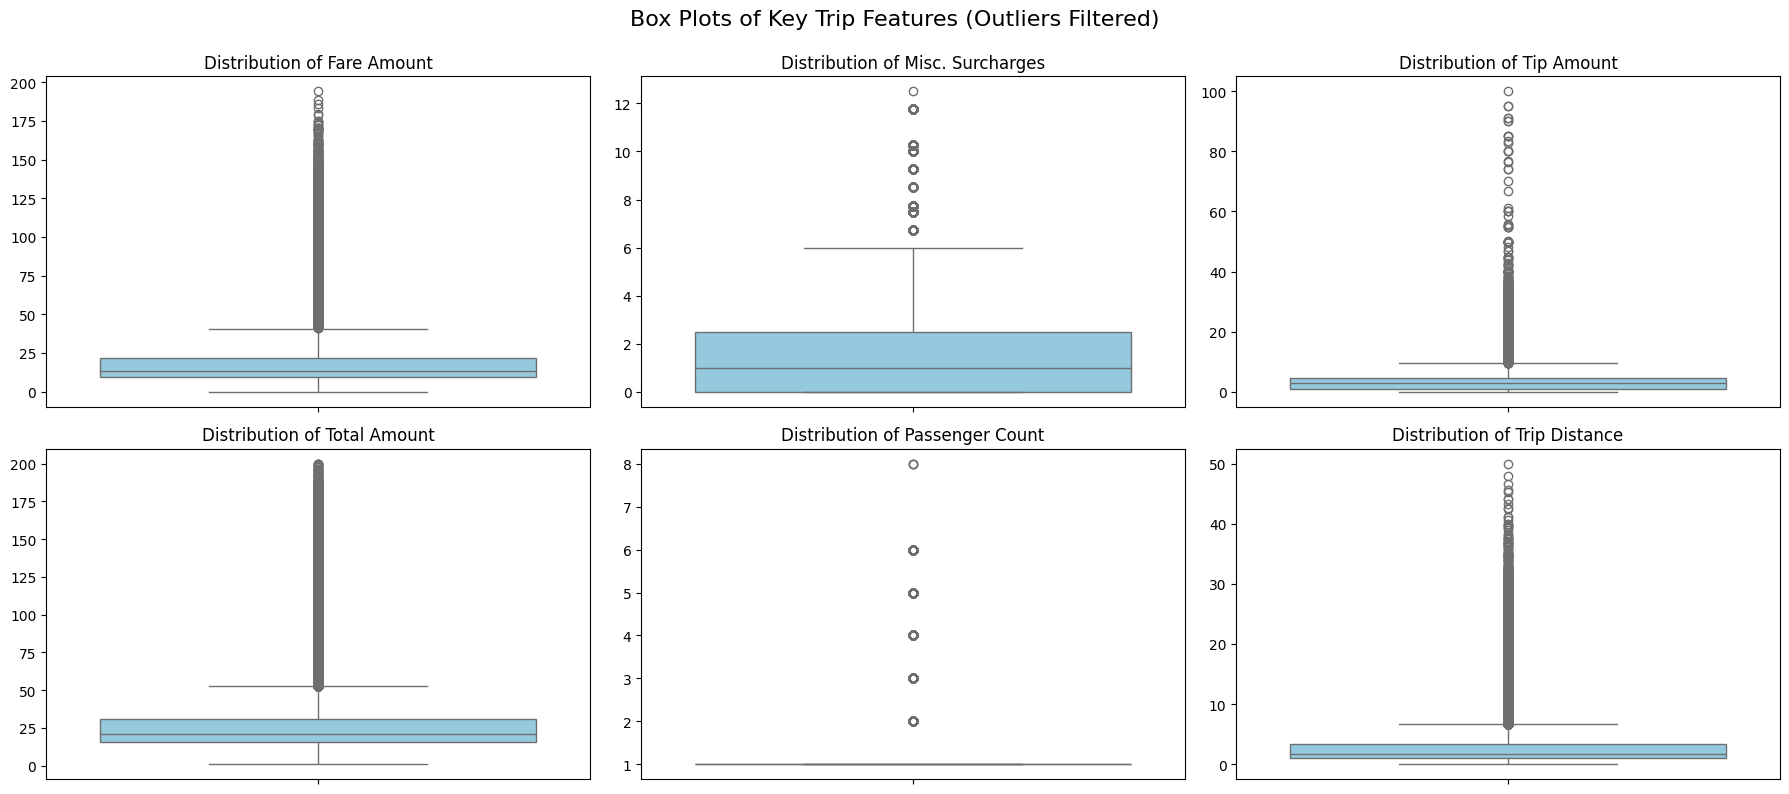


Descriptive Statistics (Median, IQR, Number of Outliers):
                 Median    IQR  Num Outliers
Fare Amount       13.50  12.60         36716
Misc. Surcharges   1.00   2.50          6227
Tip Amount         2.90   3.48         27884
Total Amount      21.00  14.76         41099
Passenger Count    1.00   0.00         77899
Trip Distance      1.72   2.28         48256


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns for box plots - focusing on monetary amounts and key trip characteristics
# extra is misc. fees like overnight surcharges and surcharges for trips that end in different states
box_plot_columns = [
    'fare_amount', 'extra', 'tip_amount',
    'total_amount', 'passenger_count', 'trip_distance'
]

# Filter out potential outliers for better visualization in box plots
# For example, filtering total_amount to a reasonable range
df_for_boxplots = combined_df_sample[(combined_df_sample['total_amount'] < 200) & (combined_df_sample['trip_distance'] < 50)]

plt.figure(figsize=(18, 15))

# Mapping for display names for both plots and statistics
display_names = {
    'fare_amount': 'Fare Amount',
    'extra': 'Misc. Surcharges',
    'tip_amount': 'Tip Amount',
    'total_amount': 'Total Amount',
    'passenger_count': 'Passenger Count',
    'trip_distance': 'Trip Distance'
}

for i, col in enumerate(box_plot_columns):
    plt.subplot(4, 3, i + 1) # Arrange in 4 rows, 3 columns
    sns.boxplot(y=df_for_boxplots[col], color='skyblue')
    # Use the display name for the title of the box plot
    plt.title(f'Distribution of {display_names.get(col, col.replace("_", " ").title())}')
    plt.ylabel('') # Remove y-label as it's redundant with title
plt.tight_layout()
plt.suptitle('Box Plots of Key Trip Features (Outliers Filtered)', y=1.02, fontsize=16)
plt.show()


# Generate descriptive statistics table
statistics_summary = pd.DataFrame(columns=['Median', 'IQR', 'Num Outliers'])

for col in box_plot_columns:
    Q1 = df_for_boxplots[col].quantile(0.25)
    Q3 = df_for_boxplots[col].quantile(0.75)
    median = df_for_boxplots[col].median()
    iqr = Q3 - Q1

    lower_bound = Q1 - 1.5 * iqr
    upper_bound = Q3 + 1.5 * iqr

    num_outliers = df_for_boxplots[(df_for_boxplots[col] < lower_bound) | (df_for_boxplots[col] > upper_bound)].shape[0]

    # Use the display name for the index
    statistics_summary.loc[display_names.get(col, col)] = [f'{median:.2f}', f'{iqr:.2f}', num_outliers]

print("\nDescriptive Statistics (Median, IQR, Number of Outliers):")
print(statistics_summary)

Most box plots are heavily skewed, especially passenger count, showing how most taxis only take 1 passenger. Incentivizing carpooing though taxis could be an effective way of reducing congestion

# 5. Trip Distance Optimization

We look at the average trip distance as a histogram, to gain more insights how long travellers usually commute.

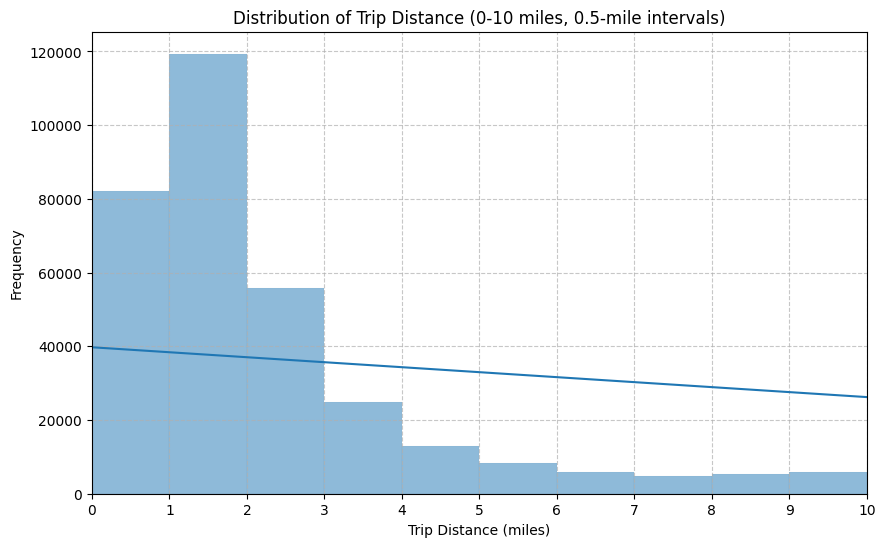

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(combined_df_sample['trip_distance'], bins=range(0, 11, 1), kde=True) # Adjusting bins for 0.5 mile intervals up to 10 miles
plt.title('Distribution of Trip Distance (0-10 miles, 0.5-mile intervals)')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Frequency')
plt.xlim(0, 10) # Set x-axis limit to zoom in
plt.xticks(range(0, 11, 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

It looks like most trips are quite short, and taxis aren't efficient for these small trips. To measure this exactly we find the number of trips less than 2 miles in 0.1 mile increments.

In [ ]:
total_trips = combined_df_sample.shape[0]

print("Percentage of trips for various short distances:")

for i in range(1, 21):
    distance = i / 10.0
    trips_less_than_x_mile = combined_df_sample[combined_df_sample['trip_distance'] < distance].shape[0]
    percentage_less_than_x_mile = (trips_less_than_x_mile / total_trips) * 100
    print(f"  Less than {distance:.1f} mile: {percentage_less_than_x_mile:.2f}%")

trips_less_than_1_mile = combined_df_sample[combined_df_sample['trip_distance'] < 1].shape[0]
trips_less_than_2_miles = combined_df_sample[combined_df_sample['trip_distance'] < 2].shape[0]

percentage_less_than_1_mile = (trips_less_than_1_mile / total_trips) * 100
percentage_less_than_2_miles = (trips_less_than_2_miles / total_trips) * 100

print(f"Less than 1 mile: {percentage_less_than_1_mile:.2f}%")
print(f"Less than 2 miles: {percentage_less_than_2_miles:.2f}%")

Percentage of trips for various short distances:
  Less than 0.1 mile: 0.29%
  Less than 0.2 mile: 0.51%
  Less than 0.3 mile: 1.03%
  Less than 0.4 mile: 2.23%
  Less than 0.5 mile: 4.25%
  Less than 0.6 mile: 7.11%
  Less than 0.7 mile: 10.64%
  Less than 0.8 mile: 14.62%
  Less than 0.9 mile: 18.82%
  Less than 1.0 mile: 23.05%
  Less than 1.1 mile: 27.23%
  Less than 1.2 mile: 31.31%
  Less than 1.3 mile: 35.19%
  Less than 1.4 mile: 38.85%
  Less than 1.5 mile: 42.33%
  Less than 1.6 mile: 45.65%
  Less than 1.7 mile: 48.74%
  Less than 1.8 mile: 51.51%
  Less than 1.9 mile: 54.13%
  Less than 2.0 mile: 56.52%
Less than 1 mile: 23.05%
Less than 2 miles: 56.52%


Clearly, most trips are quite short. Now we analyze how efficient these trips are by plotting average speed vs trip distance for 0-5 miles as well as finding the correlation coefficient. To do this we add an average speed column to our data.

In [ ]:
combined_df_sample['trip_duration'] = combined_df_sample['tpep_dropoff_datetime'] - combined_df_sample['tpep_pickup_datetime']

# Convert trip duration to hours
combined_df_sample['trip_duration_hours'] = combined_df_sample['trip_duration'] / pd.Timedelta(hours=1)

# Calculate average speed in MPH, handling potential division by zero for trip_duration_hours
# Also handle cases where trip_duration_hours might be 0, leading to infinite speed
combined_df_sample['avg_speed_mph'] = combined_df_sample.apply(lambda row: row['trip_distance'] / row['trip_duration_hours'] if row['trip_duration_hours'] > 0 else 0, axis=1)

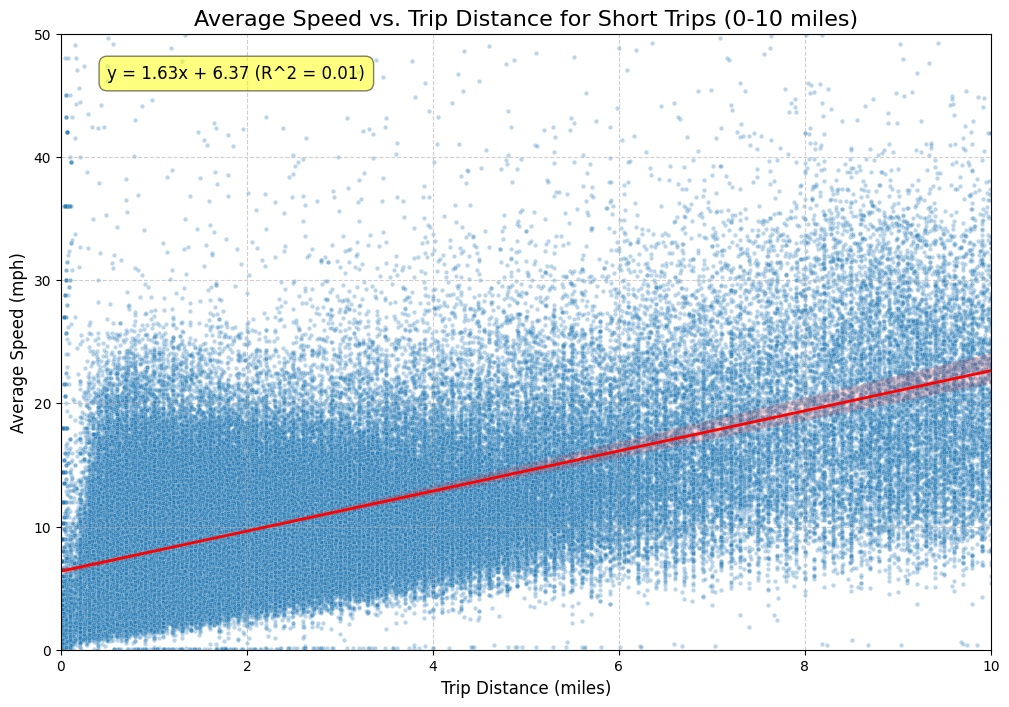

Pearson correlation between Average Speed and Trip Distance for short trips (scatterplot): 0.09


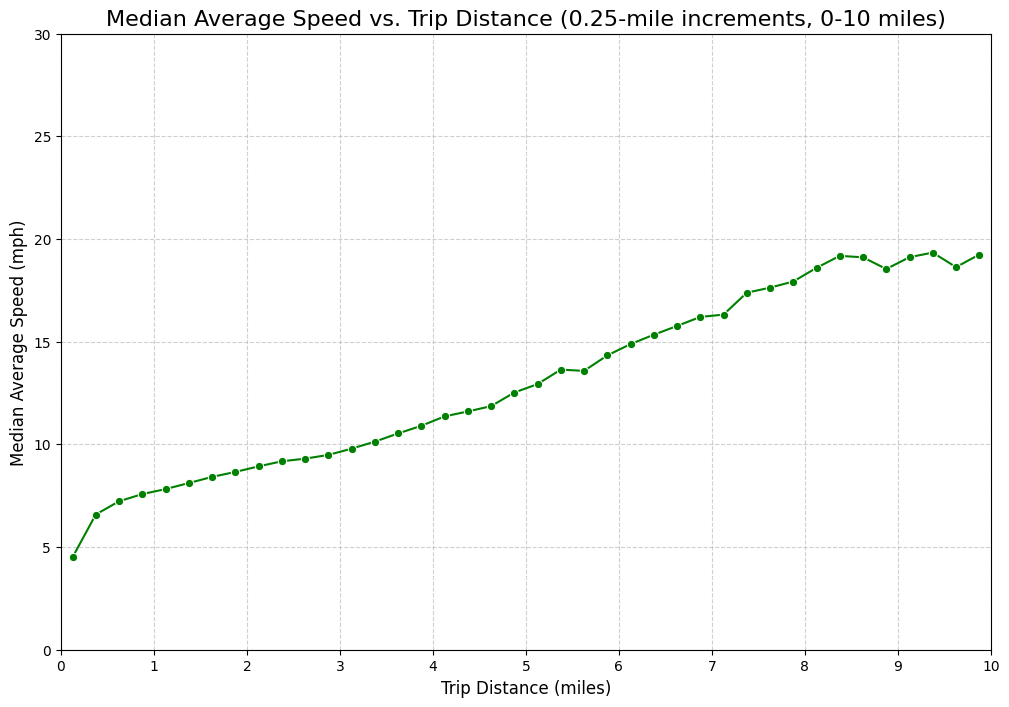

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import numpy as np

# Filter for trips with distance between 0 and 10 miles
short_trips_df = combined_df_sample[(combined_df_sample['trip_distance'] > 0) & (combined_df_sample['trip_distance'] <= 10)].copy()

# First Plot: Scatterplot with Regression Line
plt.figure(figsize=(12, 8))
sns.scatterplot(x='trip_distance', y='avg_speed_mph', data=short_trips_df, alpha=0.3, s=10)
sns.regplot(x='trip_distance', y='avg_speed_mph', data=short_trips_df, scatter=False, color='red', line_kws={'lw': 2}) # Add regression line

# Calculate linear regression to get the equation
slope, intercept, r_value, p_value, std_err = linregress(short_trips_df['trip_distance'], short_trips_df['avg_speed_mph'])
regression_eq = f'y = {slope:.2f}x + {intercept:.2f} (R^2 = {r_value**2:.2f})'
plt.text(0.05, 0.95, regression_eq, transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

plt.title('Average Speed vs. Trip Distance for Short Trips (0-10 miles)', fontsize=16)
plt.xlabel('Trip Distance (miles)', fontsize=12)
plt.ylabel('Average Speed (mph)', fontsize=12)
plt.xlim(0, 10) # Set x-axis limit to 0-10 miles for better visualization
plt.ylim(0, 50) # Set y-axis limit to 0-50 mph for better visualization
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Calculate Pearson correlation coefficient for the scatterplot data
correlation = short_trips_df['avg_speed_mph'].corr(short_trips_df['trip_distance'])
print(f"Pearson correlation between Average Speed and Trip Distance for short trips (scatterplot): {correlation:.2f}")

# --- Second Plot: Median Average Speed per 0.25-mile Increment ---
# Define bins for 0.25 mile increments up to 10 miles
bins = np.arange(0, 10.25, 0.25)

# Bin the trip_distance and calculate the median average speed for each bin
short_trips_df['trip_distance_binned'] = pd.cut(short_trips_df['trip_distance'], bins=bins, right=False, labels=bins[:-1])
mean_speed_per_bin = short_trips_df.groupby('trip_distance_binned', observed=False)['avg_speed_mph'].median().reset_index()

# Convert 'trip_distance_binned' back to numeric for plotting (midpoint of bin)
mean_speed_per_bin['trip_distance_binned'] = mean_speed_per_bin['trip_distance_binned'].astype(float) + (0.25 / 2)

plt.figure(figsize=(12, 8))
sns.lineplot(x='trip_distance_binned', y='avg_speed_mph', data=mean_speed_per_bin, marker='o', color='green')
plt.title('Median Average Speed vs. Trip Distance (0.25-mile increments, 0-10 miles)', fontsize=16)
plt.xlabel('Trip Distance (miles)', fontsize=12)
plt.ylabel('Median Average Speed (mph)', fontsize=12)
plt.xlim(0, 10) # Set x-axis limit to 0-10 miles
plt.ylim(0, 30) # Adjust y-axis for better visualization of median speeds
plt.xticks(np.arange(0, 11, 1)) # Show ticks at 1-mile intervals for clarity
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

There is visually an upward trend in the graph but the correlation coefficient is quite weak. The graph of the medians however shows that trip efficiency is much better on average when duration is longer.

In [ ]:
import pandas as pd

trips_under_1_mile = combined_df_sample[combined_df_sample['trip_distance'] < 1]
trips_1_to_2_miles = combined_df_sample[(combined_df_sample['trip_distance'] >= 1) & (combined_df_sample['trip_distance'] < 2)]

avg_speed_under_1_mile = trips_under_1_mile['avg_speed_mph'].mean()
avg_speed_1_to_2_miles = trips_1_to_2_miles['avg_speed_mph'].mean()

print(f"Average speed for trips under 1 mile: {avg_speed_under_1_mile:.2f} mph")
print(f"Average speed for trips between 1 and 2 miles: {avg_speed_1_to_2_miles:.2f} mph")

Average speed for trips under 1 mile: 7.85 mph
Average speed for trips between 1 and 2 miles: 8.70 mph


The taxi seems to take a speed comparable to biking, or scooter riding. Hence one way we can reduce traffic is by incentivizing options like scooter/bike from companies like lime for distances under 2 miles. Metro is faster and cheaper than taxis for medium to long sized trips, though taxis are often preffered for shorter trips. Incentivizing scooters & bikes could help greatly with this. However, during rainy or cold days, I hypothesize most commuters would prefer the taxi. To see if this is true we graph percent of rides under 2 miles every month to understand the effect of weather.

In [ ]:
combined_df_sample['month'] = combined_df_sample['tpep_pickup_datetime'].dt.month

monthly_trip_stats = combined_df_sample.groupby('month').agg(
    total_trips=('trip_distance', 'count'),
    short_trips=('trip_distance', lambda x: (x < 2).sum())
).reset_index()

monthly_trip_stats['percentage_short_trips'] = (monthly_trip_stats['short_trips'] / monthly_trip_stats['total_trips']) * 100

monthly_short_trips_percentage = monthly_trip_stats[['month', 'percentage_short_trips']]

print("Monthly Percentage of Trips Less Than 2 Miles:")
print(monthly_short_trips_percentage)

Monthly Percentage of Trips Less Than 2 Miles:
    month  percentage_short_trips
0       1               57.792018
1       2               57.435595
2       3               56.549797
3       4               56.578991
4       5               56.049689
5       6               55.679788
6       7               55.531285
7       8               54.696281
8       9               55.201832
9      10               56.125080
10     11               57.906071
11     12               58.430115


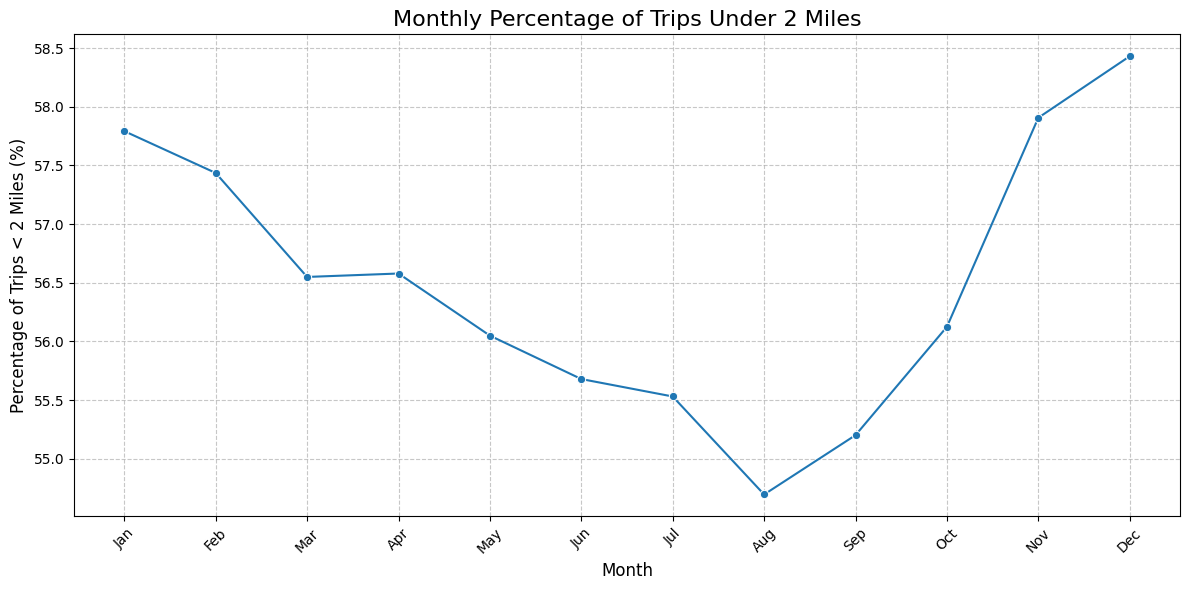

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x='month', y='percentage_short_trips', data=monthly_short_trips_percentage, marker='o')
plt.title('Monthly Percentage of Trips Under 2 Miles', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Percentage of Trips < 2 Miles (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.tight_layout()
plt.show()

There is a dip in the graph during summer months like Jun/Jul/Aug, while winter months like december and Jan have the highest average percent. Granted the percentage doesn't change much, at highest its just below 58.5% and at lowest its just above 54.5%. We see that incentivising bikes & scooters would help more in the summer months.

In [ ]:
combined_df_sample['month'] = combined_df_sample['tpep_pickup_datetime'].dt.month

monthly_median_avg_speed = combined_df_sample.groupby('month')['avg_speed_mph'].median().reset_index()

print("Monthly Median Average Speed:")
print(monthly_median_avg_speed.head(12))

Monthly Median Average Speed:
    month  avg_speed_mph
0       1       9.640167
1       2       9.473684
2       3       9.567487
3       4       9.380711
4       5       9.115139
5       6       9.397496
6       7       9.569541
7       8       9.627434
8       9       8.894065
9      10       8.724783
10     11       8.727273
11     12       8.597015


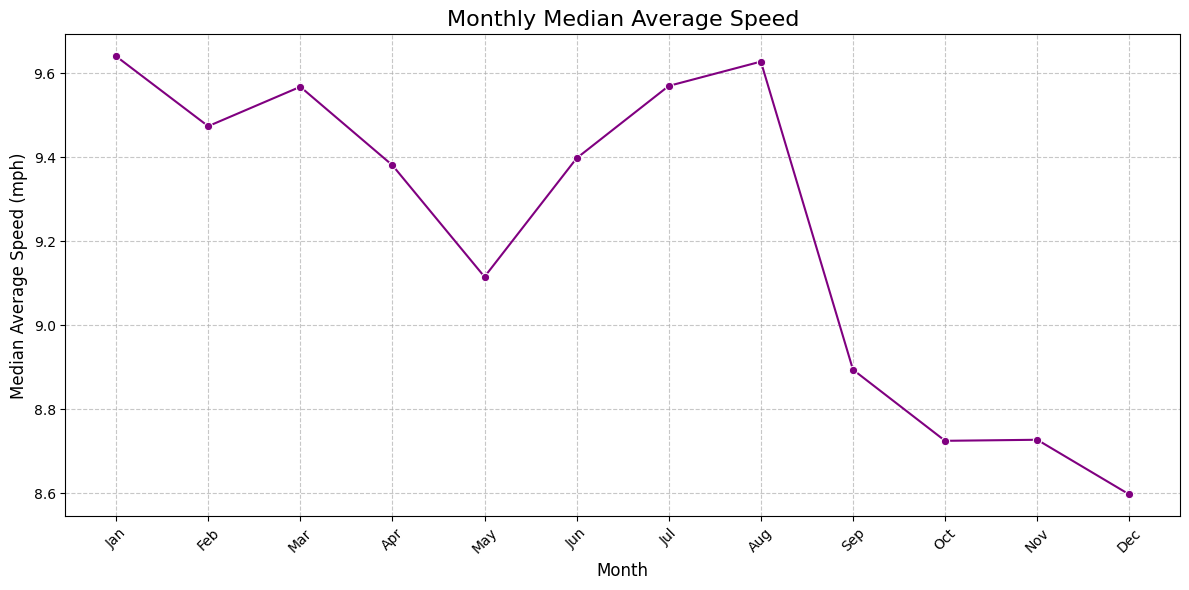

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x='month', y='avg_speed_mph', data=monthly_median_avg_speed, marker='o', color='purple')
plt.title('Monthly Median Average Speed', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Median Average Speed (mph)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.tight_layout()
plt.show()

As shown by the graph, average speed does rise in the summer months, and incentivizing scooters/bikes could optimize this even more. Interestingly though, the graph peaks in January. I hypothesize this is because the weather is so cold people don't want to come outside, and it being just after the holidays.To test this, we look at the total number of trips in each month. However, we see that incentivizing bikes/scooters would help, but mostly in the months that are already the most efficient.

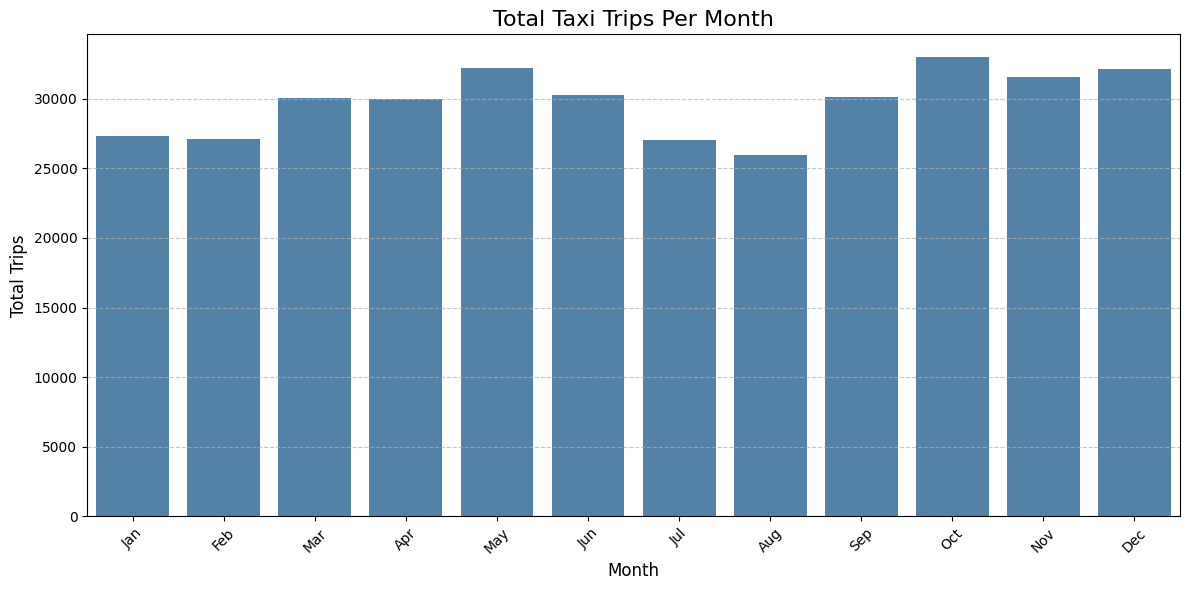

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.barplot(x='month', y='total_trips', data=monthly_trip_stats, color='steelblue', legend=False)

plt.title('Total Taxi Trips Per Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Trips', fontsize=12)
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Quite intuitively, this graph has an almost inverse relationship with the previous one. Months with less trips have higher average commute speeds. The low number of trips in January could be due to the weather, vacations or some other factor.

# 6. Congestion vs Time of Day

We look at median average speed vs time of day, to understand when congestion is highest and how it can be optimized.

In [ ]:
# --- Task Specific Calculations ---

print("\nFirst 5 rows with new trip_duration, trip_duration_hours, and avg_speed_mph:")
print(combined_df_sample[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_duration', 'trip_duration_hours', 'trip_distance', 'avg_speed_mph']].head())

print("\nDescriptive statistics for avg_speed_mph:")
print(combined_df_sample['avg_speed_mph'].describe())


First 5 rows with new trip_duration, trip_duration_hours, and avg_speed_mph:
  tpep_pickup_datetime tpep_dropoff_datetime   trip_duration  \
0  2024-01-01 00:35:22   2024-01-01 00:41:41 0 days 00:06:19   
2  2024-01-01 00:54:16   2024-01-01 01:27:40 0 days 00:33:24   
3  2024-01-01 00:57:57   2024-01-01 01:09:57 0 days 00:12:00   
4  2024-01-01 00:42:42   2024-01-01 01:08:50 0 days 00:26:08   
5  2024-01-01 00:30:33   2024-01-01 00:42:18 0 days 00:11:45   

   trip_duration_hours  trip_distance  avg_speed_mph  
0             0.105278           0.75       7.124011  
2             0.556667          13.74      24.682635  
3             0.200000           2.17      10.850000  
4             0.435556          10.51      24.130102  
5             0.195833           2.23      11.387234  

Descriptive statistics for avg_speed_mph:
count    356709.000000
mean         11.397718
std          77.665857
min           0.002825
25%           6.804124
50%           9.215017
75%          12.755906
max

In [ ]:
import pandas as pd

# Define the function to get all active 5-minute intervals for a trip
def get_active_5min_intervals(row):
    pickup_dt = row['tpep_pickup_datetime']
    dropoff_dt = row['tpep_dropoff_datetime']

    active_intervals_list = []
    current_time = pickup_dt

    while current_time <= dropoff_dt:
        # Calculate the 5-minute interval index
        # (current_time.hour * 60 + current_time.minute) gives minutes from midnight.
        # Dividing by 5 gives the 5-min interval index (0-287 for 24 hours * 12 intervals/hour).
        interval_index = (current_time.hour * 60 + current_time.minute) // 5
        active_intervals_list.append(interval_index)

        # Increment current_time by 5 minutes
        current_time += pd.Timedelta(minutes=5)

    # Ensure unique and sorted intervals
    return sorted(list(set(active_intervals_list)))

# Apply the function to get the list of active 5-minute intervals for each trip
df_with_active_5min_intervals = combined_df_sample.copy()
df_with_active_5min_intervals['active_5min_intervals'] = df_with_active_5min_intervals.apply(get_active_5min_intervals, axis=1)

# Explode the DataFrame so each active 5-minute interval becomes a separate row
df_exploded_5min = df_with_active_5min_intervals.explode('active_5min_intervals')
df_exploded_5min.rename(columns={'active_5min_intervals': 'five_min_interval_of_day'}, inplace=True)

In [ ]:
df_exploded_5min['trip_duration'] = df_exploded_5min['tpep_dropoff_datetime'] - df_exploded_5min['tpep_pickup_datetime']
df_exploded_5min['trip_duration_hours'] = df_exploded_5min['trip_duration'] / pd.Timedelta(hours=1)
df_exploded_5min['avg_speed_mph'] = df_exploded_5min.apply(lambda row: row['trip_distance'] / row['trip_duration_hours'] if row['trip_duration_hours'] > 0 else 0, axis=1)

hourly_avg_speed_median_5min = df_exploded_5min.groupby('five_min_interval_of_day')['avg_speed_mph'].median().reset_index()

print("Median Average Speed per 5-Minute Interval of Day (first 5 rows):")
print(hourly_avg_speed_median_5min.head())

Median Average Speed per 5-Minute Interval of Day (first 5 rows):
   five_min_interval_of_day  avg_speed_mph
0                         0      12.543950
1                         1      12.618026
2                         2      12.597305
3                         3      12.709649
4                         4      12.648392


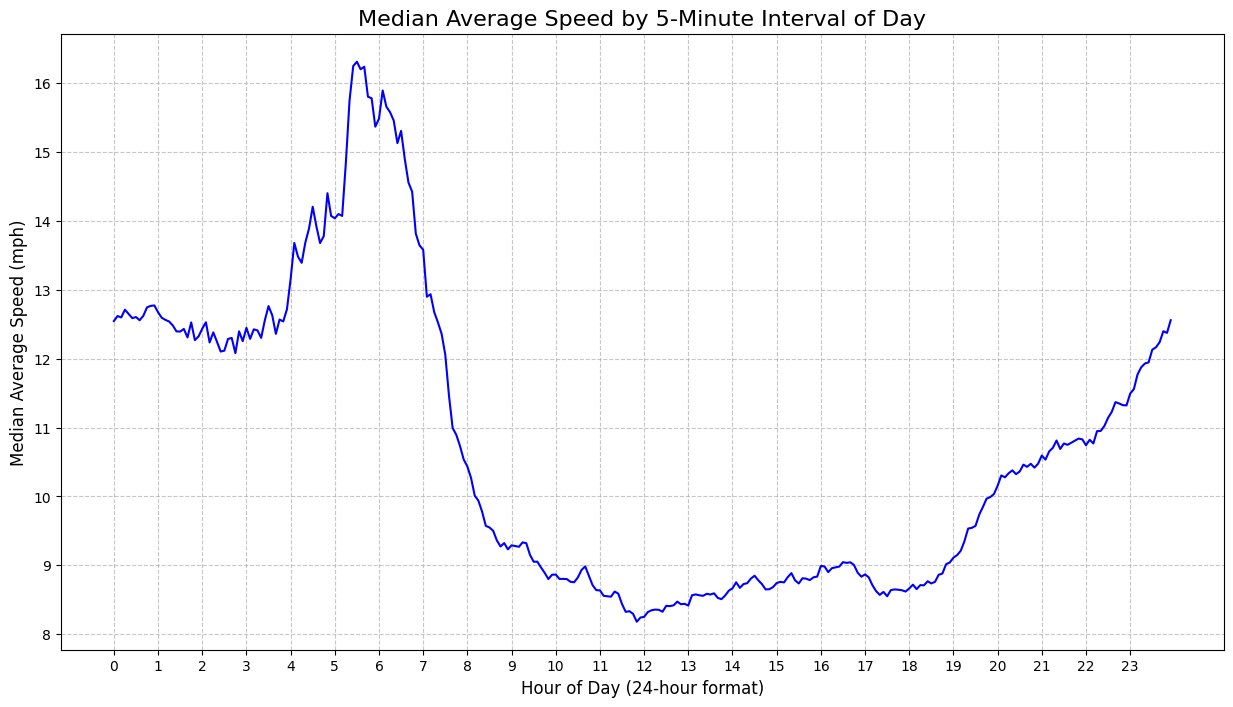

In [ ]:
plt.figure(figsize=(15, 8))
sns.lineplot(x='five_min_interval_of_day', y='avg_speed_mph', data=hourly_avg_speed_median_5min, marker=None, color='blue')
plt.title('Median Average Speed by 5-Minute Interval of Day', fontsize=16)
plt.xlabel('Hour of Day (24-hour format)', fontsize=12)
plt.ylabel('Median Average Speed (mph)', fontsize=12)

hour_ticks = range(0, 288, 12) # Ticks every 12 intervals (every hour)
hour_labels = [str(i // 12) for i in hour_ticks] # Map interval index to hour
plt.xticks(hour_ticks, hour_labels)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

We note that the median average speed drops most around noon, to mid-evening and is most efficent between 4 and 7 am. To get a better picture of extremes we also map the 90th percentile speed for each time of day.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the 90th percentile of avg_speed_mph for each 5-minute interval
hourly_avg_speed_90th_percentile_5min = df_exploded_5min.groupby('five_min_interval_of_day')['avg_speed_mph'].quantile(0.90).reset_index()

print("90th Percentile Average Speed per 5-Minute Interval of Day (first 5 rows):")
print(hourly_avg_speed_90th_percentile_5min.head())

90th Percentile Average Speed per 5-Minute Interval of Day (first 5 rows):
   five_min_interval_of_day  avg_speed_mph
0                         0      30.385548
1                         1      30.467843
2                         2      30.914113
3                         3      30.947368
4                         4      30.957085


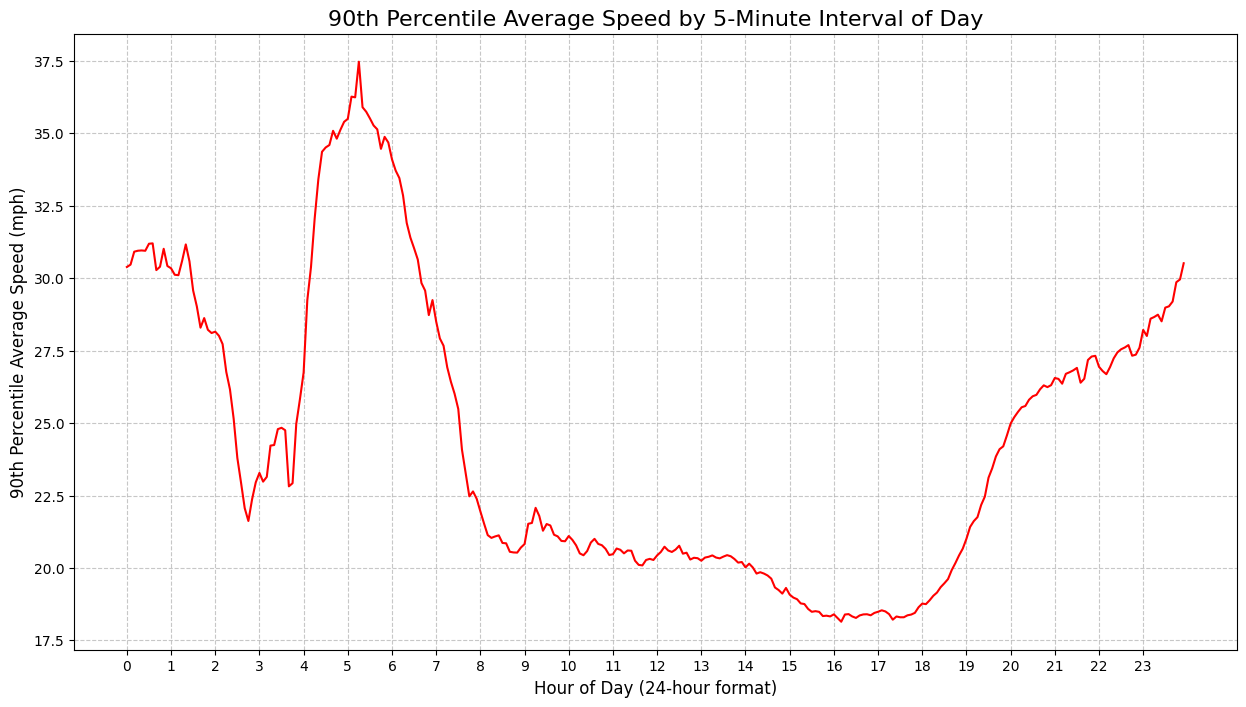

In [ ]:
plt.figure(figsize=(15, 8))
sns.lineplot(x='five_min_interval_of_day', y='avg_speed_mph', data=hourly_avg_speed_90th_percentile_5min, marker=None, color='red')
plt.title('90th Percentile Average Speed by 5-Minute Interval of Day', fontsize=16)
plt.xlabel('Hour of Day (24-hour format)', fontsize=12)
plt.ylabel('90th Percentile Average Speed (mph)', fontsize=12)

hour_ticks = range(0, 288, 12) # Ticks every 12 intervals (every hour)
hour_labels = [str(i // 12) for i in hour_ticks] # Map interval index to hour
plt.xticks(hour_ticks, hour_labels)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This graph has a similar shape with larger peaks at early morning hours and a large drop shortly after. The difference si extremely large, the 90th percentile at 5pm is twice as slow as at 5am. Next we look at weekend vs weekday patterns to see if they shift on weekdays when people commute to work.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add a 'day_of_week' column to identify weekdays (0-4) and weekends (5-6)
combined_df_sample['day_of_week'] = combined_df_sample['tpep_pickup_datetime'].dt.dayofweek
combined_df_sample['is_weekend'] = combined_df_sample['day_of_week'].isin([5, 6])

# Calculate median average speed for weekdays vs. weekends
median_speed_by_day_type = combined_df_sample.groupby('is_weekend')['avg_speed_mph'].median().reset_index()
median_speed_by_day_type['day_type'] = median_speed_by_day_type['is_weekend'].map({False: 'Weekday', True: 'Weekend'})

print("Median Average Speed (mph) for Weekdays vs. Weekends:")
print(median_speed_by_day_type)

Median Average Speed (mph) for Weekdays vs. Weekends:
   is_weekend  avg_speed_mph day_type
0       False       8.910398  Weekday
1        True      10.014085  Weekend


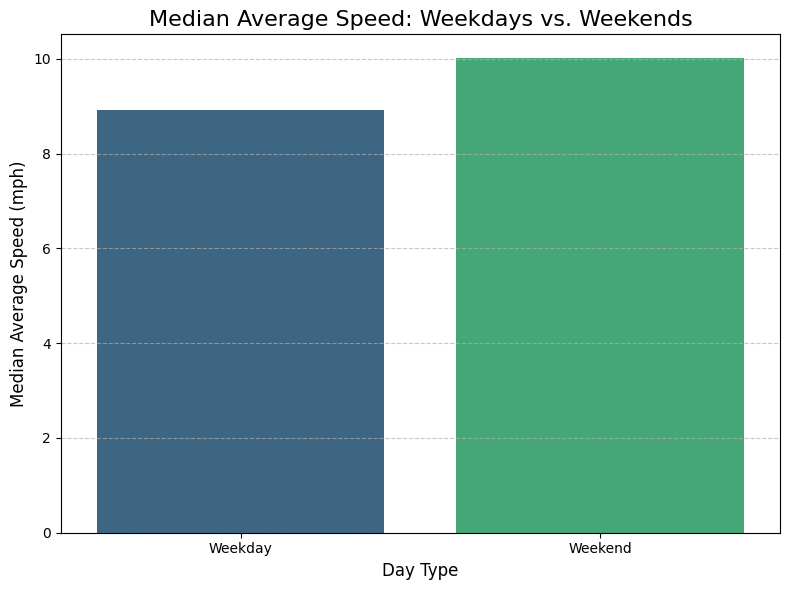

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x='day_type', y='avg_speed_mph', data=median_speed_by_day_type, palette='viridis', hue='day_type', legend=False)
plt.title('Median Average Speed: Weekdays vs. Weekends', fontsize=16)
plt.xlabel('Day Type', fontsize=12)
plt.ylabel('Median Average Speed (mph)', fontsize=12)
plt.ylim(bottom=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
df_exploded_5min_with_day_type = pd.merge(
    df_exploded_5min,
    combined_df_sample[['tpep_pickup_datetime', 'is_weekend']].drop_duplicates(subset=['tpep_pickup_datetime']),
    on='tpep_pickup_datetime',
    how='left'
)

# Calculate median average speed per 5-minute interval for weekdays
hourly_avg_speed_median_5min_weekday = (df_exploded_5min_with_day_type[df_exploded_5min_with_day_type['is_weekend'] == False]
    .groupby('five_min_interval_of_day')['avg_speed_mph'].median().reset_index())

# Calculate median average speed per 5-minute interval for weekends
hourly_avg_speed_median_5min_weekend = (df_exploded_5min_with_day_type[df_exploded_5min_with_day_type['is_weekend'] == True]
    .groupby('five_min_interval_of_day')['avg_speed_mph'].median().reset_index())

print("Median Average Speed per 5-Minute Interval (Weekdays - first 5 rows):")
print(hourly_avg_speed_median_5min_weekday.head())

print("\nMedian Average Speed per 5-Minute Interval (Weekends - first 5 rows):")
print(hourly_avg_speed_median_5min_weekend.head())

Median Average Speed per 5-Minute Interval (Weekdays - first 5 rows):
   five_min_interval_of_day  avg_speed_mph
0                         0      13.679581
1                         1      14.190476
2                         2      14.354430
3                         3      14.703936
4                         4      14.868586

Median Average Speed per 5-Minute Interval (Weekends - first 5 rows):
   five_min_interval_of_day  avg_speed_mph
0                         0      10.775906
1                         1      10.772409
2                         2      10.527355
3                         3      10.493415
4                         4      10.501083


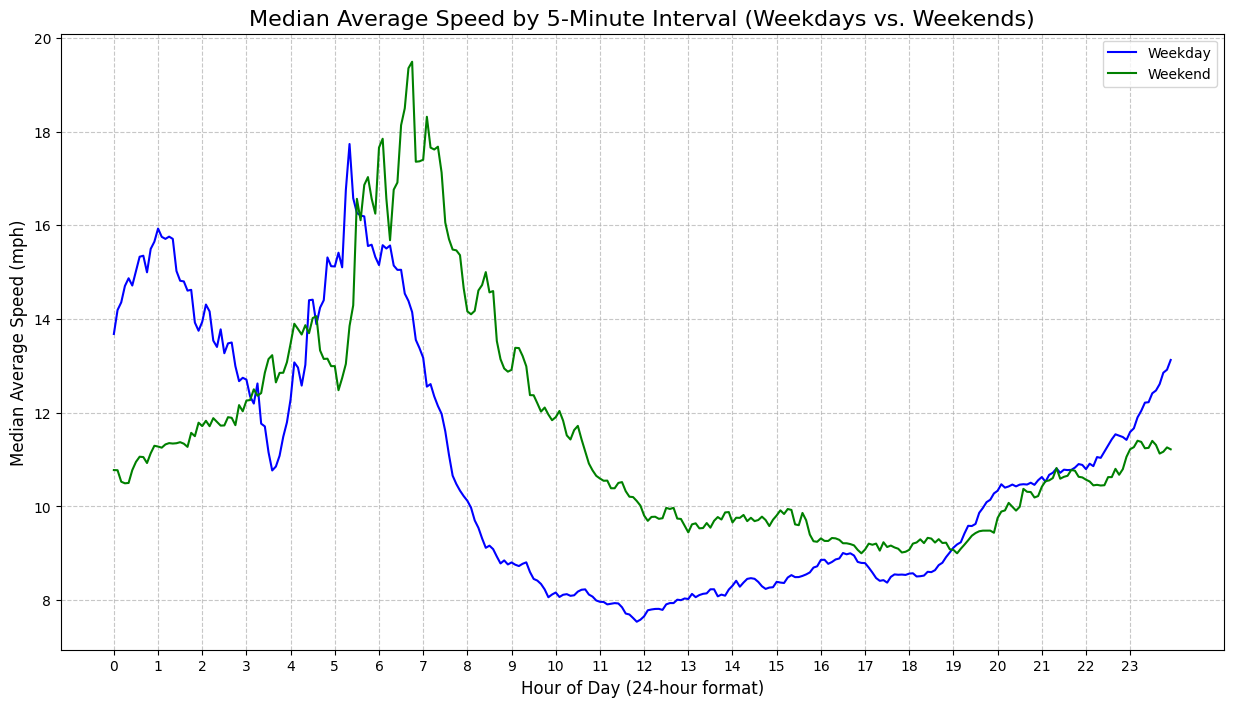

In [ ]:
plt.figure(figsize=(15, 8))

sns.lineplot(x='five_min_interval_of_day', y='avg_speed_mph', data=hourly_avg_speed_median_5min_weekday, marker=None, color='blue', label='Weekday')
sns.lineplot(x='five_min_interval_of_day', y='avg_speed_mph', data=hourly_avg_speed_median_5min_weekend, marker=None, color='green', label='Weekend')

plt.title('Median Average Speed by 5-Minute Interval (Weekdays vs. Weekends)', fontsize=16)
plt.xlabel('Hour of Day (24-hour format)', fontsize=12)
plt.ylabel('Median Average Speed (mph)', fontsize=12)

hour_ticks = range(0, 288, 12)
hour_labels = [str(i // 12) for i in hour_ticks]
plt.xticks(hour_ticks, hour_labels)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Interestingly, weekends are slower for most of the late night, from 7pm to 3 am, which is likely due to people staying up late on weekends. Both weekdays and weekends dip for most of the day, from 8 am to 8 pm. Interestingly, the weekdays dips sharply around 3-4 am, and then rises directly after. I hypothesize this is due to workers with early shifts as well as truck drivers with supplies commuting, creating some congestion.

# 7. Dynamic Pricing Simulation

Clearly some times of day are more efficient than others. This leads us to consider dynamic pricing when traffic is high. The higher price would make some people decide to use other, more efficient forms of transport like the metro. This would overall reduce traffic. Further, taxi driviers driving through traffic get the same amount of money but spend more time due to the congestion. So this gives them money they deserve for the extra time. Based on the graph we propose a 10 dollar surcharge for any ride picked up between 8 am and 8 pm. NYC has already succesfully implemented a congestion surcharge for cars passing through Manhattan below 61st street, which has reduced traffic in the area noticeably. So, this would likely be an effective strategy. Additionally, this would create a large percent increase in cost for smaller trips, de-incentivizing these inefficient small trips even more.

To understand the impact of such dynamic pricing, we simulate its effects at different price elasticities (the fraction of people that would refuse after a 10% price increase)

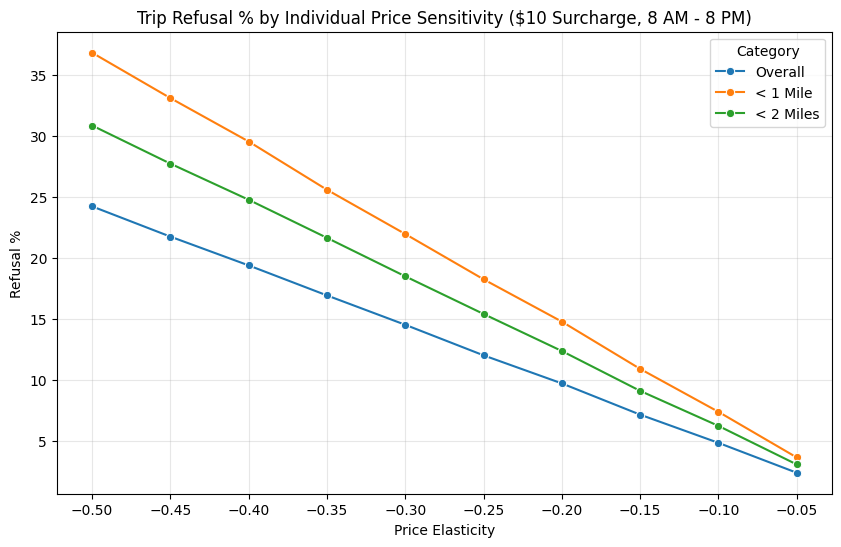

,elasticity,Overall,< 1 Mile,< 2 Miles
0,-0.05,2.402479,3.656812,3.083264
1,-0.10,4.852761,7.397481,6.243419
2,-0.15,7.164992,10.917820,9.115406
3,-0.20,9.726126,14.791674,12.381546
4,-0.25,12.028467,18.262685,15.419784
5,-0.30,14.532320,21.975402,18.505819
6,-0.35,16.940569,25.604262,21.661125
7,-0.40,19.400740,29.560328,24.783181
8,-0.45,21.761186,33.120129,27.745220
9,-0.50,24.241138,36.841067,30.872818


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for surcharge period (8 AM - 8 PM)
surcharge_period_df = combined_df_sample[
    (combined_df_sample['tpep_pickup_datetime'].dt.hour >= 8) &
    (combined_df_sample['tpep_pickup_datetime'].dt.hour < 20)
].copy()

# Individual percentage price change for a $10 surcharge
surcharge_period_df['pct_increase'] = (10.0 / surcharge_period_df['total_amount']) * 100

price_elasticities = [-0.05, -0.1, -0.15, -0.2, -0.25, -0.3, -0.35, -0.4, -0.45, -0.5]
results = []
np.random.seed(42) # random seed for reproducibility

for elasticity in price_elasticities:
    # Probability of refusal = elasticity * pct_increase (converted to positive probability)
    # e.g., -0.5 * 20% increase = 10% chance of refusal
    probs = (surcharge_period_df['pct_increase'] * -elasticity / 100).clip(0, 1)
    refusals = np.random.rand(len(surcharge_period_df)) < probs

    # Calculate percentages for different categories
    results.append({
        'elasticity': elasticity,
        'Overall': (refusals.mean()) * 100, # mean gives percentage since refusals are counted as 1s, while non-refusals counted as 0.
        '< 1 Mile': (refusals[surcharge_period_df['trip_distance'] < 1].mean()) * 100,
        '< 2 Miles': (refusals[surcharge_period_df['trip_distance'] < 2].mean()) * 100
    })

# Visualization
df_res = pd.DataFrame(results).melt(id_vars='elasticity', var_name='Category', value_name='Refusal %')
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_res, x='elasticity', y='Refusal %', hue='Category', marker='o')
plt.title('Trip Refusal % by Individual Price Sensitivity ($10 Surcharge, 8 AM - 8 PM)')
plt.xlabel('Price Elasticity')
plt.ylabel('Refusal %')
plt.xticks(ticks=price_elasticities) # Set x-ticks to show all elasticity values
plt.grid(True, alpha=0.3)
plt.show()

display(pd.DataFrame(results))

We see that it has quite a significant effect, especially on the inefficient shorter trips, though it does depend heavily on price elasticity. Effects could range from a 2% to 25% decrease in overall trips. A study with New Yorkers could be done to figure out what the price elasticity would actually be, and the surcharge could be adjusted accordingly.

# 8. Inefficient Zone Mapping

We look at the top 10 most inefficient zones.

In [ ]:
# Group by PU and DO locations to find slowest routes
route_stats = combined_df_sample.groupby(['PULocationID', 'DOLocationID']).agg(
    median_speed_mph=('avg_speed_mph', 'median'),
    trip_count=('VendorID', 'count')
).reset_index()

# Filter for routes with at least 50 trips to ensure statistical significance
significant_routes = route_stats[route_stats['trip_count'] >= 50].copy()

# Sort by median speed to find the slowest routes
slowest_10_routes = significant_routes.sort_values(by='median_speed_mph', ascending=True).head(10)

print("Top 10 Slowest Routes (Minimum 50 trips):")
print(slowest_10_routes)

Top 10 Slowest Routes (Minimum 50 trips):
      PULocationID  DOLocationID  median_speed_mph  trip_count
8006           186           100          3.880154         222
9434           230           230          4.198251         445
7082           162           230          4.310108         433
8084           186           230          4.401099         839
9790           233           230          4.468619         149
6923           161           230          4.494382         571
7045           162           161          4.506851         474
3883           100           100          4.543436         116
7307           164           100          4.835821         137
9722           233           100          4.938878          72


In [ ]:
import pandas as pd

# Filter combined_df_sample for the 10 slowest routes
# Create a helper key for filtering
slowest_keys = slowest_10_routes[['PULocationID', 'DOLocationID']].apply(tuple, axis=1).tolist()

# Filter the original sampled dataframe
slow_routes_detail = combined_df_sample[combined_df_sample[['PULocationID', 'DOLocationID']].apply(tuple, axis=1).isin(slowest_keys)].copy()

# Calculate mean trip distance and 4. extract hour for time-of-day analysis
slow_routes_detail['pickup_hour'] = slow_routes_detail['tpep_pickup_datetime'].dt.hour

# Group the details
route_characteristics = slow_routes_detail.groupby(['PULocationID', 'DOLocationID']).agg(
    mean_trip_distance=('trip_distance', 'mean'),
    mode_pickup_hour=('pickup_hour', lambda x: x.mode().iloc[0] if not x.mode().empty else None)
).reset_index()

# Merge statistics back with the summary table
slowest_10_analysis = slowest_10_routes.merge(
    route_characteristics,
    on=['PULocationID', 'DOLocationID'],
    how='left'
)

print("Top 10 Slowest Routes with Distance and Time Characteristics:")
print(slowest_10_analysis.sort_values(by='median_speed_mph'))

Top 10 Slowest Routes with Distance and Time Characteristics:
   PULocationID  DOLocationID  median_speed_mph  trip_count  \
0           186           100          3.880154         222   
1           230           230          4.198251         445   
2           162           230          4.310108         433   
3           186           230          4.401099         839   
4           233           230          4.468619         149   
5           161           230          4.494382         571   
6           162           161          4.506851         474   
7           100           100          4.543436         116   
8           164           100          4.835821         137   
9           233           100          4.938878          72   

   mean_trip_distance  mode_pickup_hour  
0            0.788468                13  
1            0.670404                18  
2            0.905242                18  
3            1.022431                12  
4            1.119799             

To see what locations the zone IDs refer to, we use a zone lookup table

In [ ]:
import pandas as pd

# URL for the Taxi Zone Lookup Table
zones_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

try:
    zones_df = pd.read_csv(zones_url)
    print("Taxi Zone Lookup Table loaded successfully.")
    display(zones_df.head())
except Exception as e:
    print(f"Error loading lookup table: {e}")

Taxi Zone Lookup Table loaded successfully.


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [ ]:
import pandas as pd

# Calculate median avg_speed_mph for pickup and dropoff locations separately
pu_medians = combined_df_sample.groupby('PULocationID')['avg_speed_mph'].median().reset_index()
pu_medians.columns = ['LocationID', 'pickup_median_speed']

do_medians = combined_df_sample.groupby('DOLocationID')['avg_speed_mph'].median().reset_index()
do_medians.columns = ['LocationID', 'dropoff_median_speed']

# Merge these two sets of median speeds by Location ID
zone_speeds = pd.merge(pu_medians, do_medians, on='LocationID', how='outer')

zone_speeds['combined_median_speed'] = zone_speeds[['pickup_median_speed', 'dropoff_median_speed']].mean(axis=1)

inefficient_zones = pd.merge(zone_speeds, zones_df[['LocationID', 'Borough', 'Zone']], on='LocationID', how='left')

# Sort by combined_median_speed to find the slowest zones
inefficient_zones_sorted = inefficient_zones.sort_values(by='combined_median_speed', ascending=True)

print("Top 10 most inefficient taxi zones (based on median speeds):")
print(inefficient_zones_sorted[['Borough', 'Zone', 'combined_median_speed']].head(10))

Top 10 most inefficient taxi zones (based on median speeds):
       Borough                          Zone  combined_median_speed
177      Bronx               Pelham Bay Park               4.718218
97   Manhattan              Garment District               7.074319
154  Manhattan                Midtown Center               7.197026
179  Manhattan  Penn Station/Madison Sq West               7.366872
221  Manhattan     Times Sq/Theatre District               7.587829
156  Manhattan                 Midtown North               7.728386
157  Manhattan                 Midtown South               7.820177
155  Manhattan                  Midtown East               7.846369
163  Manhattan                   Murray Hill               7.903672
228  Manhattan         Upper East Side South               8.028323


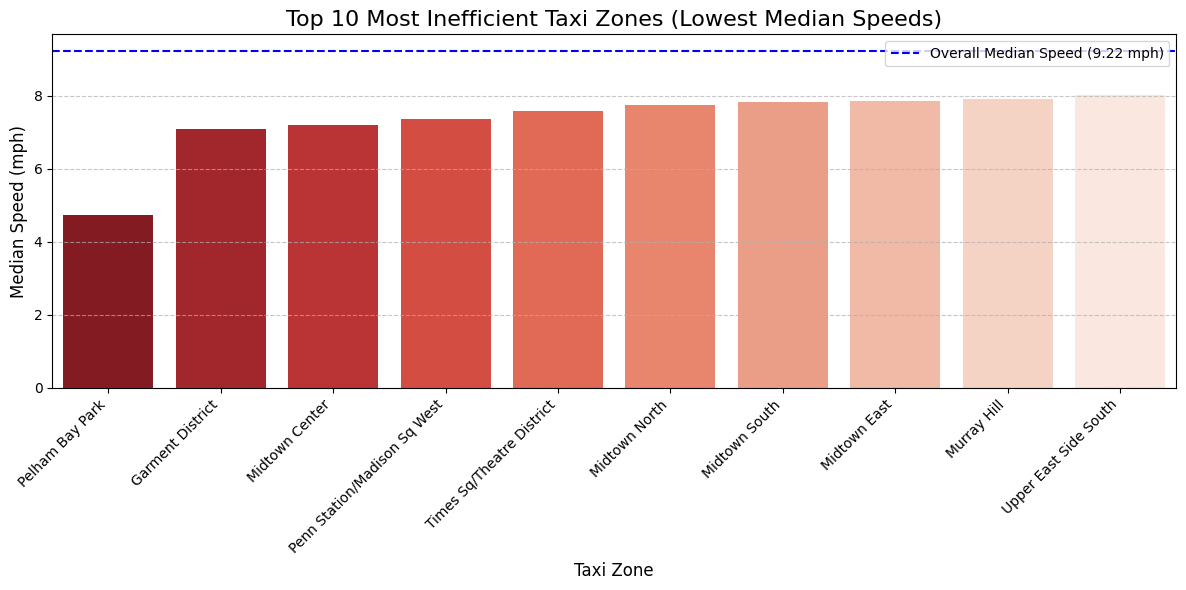

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get top 10 slowest zones
inefficient_top10 = inefficient_zones_sorted.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=inefficient_top10,
    x='Zone',
    y='combined_median_speed',
    hue='Zone',
    palette='Reds_r',
    legend=False
)

# Add baseline for comparison
overall_median = combined_df_sample['avg_speed_mph'].median()
plt.axhline(overall_median, color='blue', linestyle='--', label=f'Overall Median Speed ({overall_median:.2f} mph)')

plt.title('Top 10 Most Inefficient Taxi Zones (Lowest Median Speeds)', fontsize=16)
plt.xlabel('Taxi Zone', fontsize=12)
plt.ylabel('Median Speed (mph)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

We now map these locations out to see how close they are to each other.


In [ ]:
import folium
import pandas as pd
from branca.element import Element

# Static coordinates for the top 10 bottleneck zones
bottleneck_data = [
    {'Zone': 'Pelham Bay Park', 'lat': 40.8647, 'lon': -73.8042, 'speed': 4.718218},
    {'Zone': 'Garment District', 'lat': 40.7536, 'lon': -73.9904, 'speed': 7.074319},
    {'Zone': 'Midtown Center', 'lat': 40.7597, 'lon': -73.9786, 'speed': 7.197026},
    {'Zone': 'Penn Station/Madison Sq West', 'lat': 40.7505, 'lon': -73.9934, 'speed': 7.366872},
    {'Zone': 'Times Sq/Theatre District', 'lat': 40.7580, 'lon': -73.9855, 'speed': 7.587829},
    {'Zone': 'Midtown North', 'lat': 40.7643, 'lon': -73.9737, 'speed': 7.728386},
    {'Zone': 'Midtown South', 'lat': 40.7485, 'lon': -73.9856, 'speed': 7.820177},
    {'Zone': 'Midtown East', 'lat': 40.7551, 'lon': -73.9712, 'speed': 7.846369},
    {'Zone': 'Murray Hill', 'lat': 40.7481, 'lon': -73.9783, 'speed': 7.903672},
    {'Zone': 'Upper East Side South', 'lat': 40.7667, 'lon': -73.9614, 'speed': 8.028323}
]

map_df = pd.DataFrame(bottleneck_data)

# Initialize map with default scale (which is accurate in km)
nyc_map = folium.Map(location=[40.7580, -73.9855], zoom_start=13, tiles='cartodbpositron', control_scale=True)

# CSS to make the metric scale bar large and readable
custom_style = """
<style>
.leaflet-control-scale-line {
    font-size: 18px !important;
    height: 25px !important;
    border: 3px solid #777 !important;
    border-top: none !important;
    line-height: 1.2 !important;
    background: rgba(255, 255, 255, 0.7) !important;
}
</style>
"""
nyc_map.get_root().header.add_child(Element(custom_style))

def get_color(speed):
    if speed < 6: return '#d7191c'
    elif speed < 7.5: return '#f4a582'
    else: return '#fdae61'

for _, row in map_df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=10,
        popup=f"Zone: {row['Zone']}<br>Median Speed: {row['speed']:.2f} mph",
        color=get_color(row['speed']),
        fill=True,
        fill_color=get_color(row['speed']),
        fill_opacity=0.8
    ).add_to(nyc_map)

title_html = '<h3 align="center" style="font-size:16px"><b>Top 10 Congestion Bottlenecks</b></h3>'
nyc_map.get_root().html.add_child(folium.Element(title_html))

display(nyc_map)

Most of the locations except Pelham Bay park are within a miles of each other. This is a super touristy area containing times square and many famous brand stores. Hence it is hard to avoid this. However, routes between these zones can be optimized by bikes/scooters since they are so close together. We look at the most inefficient zone to zone routes to see if anything more can be said.

In [ ]:
import pandas as pd

# Map pickup neighborhood names
slowest_10_named = pd.merge(
    slowest_10_analysis,
    zones_df[['LocationID', 'Zone']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
).rename(columns={'Zone': 'PU_Zone'}).drop(columns=['LocationID'])

# Map dropoff neighborhood names
slowest_10_named = pd.merge(
    slowest_10_named,
    zones_df[['LocationID', 'Zone']],
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
).rename(columns={'Zone': 'DO_Zone'}).drop(columns=['LocationID'])

slowest_10_named['Route Name'] = slowest_10_named['PU_Zone'] + ' -> ' + slowest_10_named['DO_Zone']

final_display_cols = ['Route Name', 'median_speed_mph', 'trip_count', 'mean_trip_distance', 'mode_pickup_hour']
print("Top 10 Slowest Routes with Neighborhood Names:")
display(slowest_10_named[final_display_cols].sort_values(by='median_speed_mph'))

Top 10 Slowest Routes with Neighborhood Names:


,Route Name,median_speed_mph,trip_count,mean_trip_distance,mode_pickup_hour
0,Penn Station/Madison Sq West -> Garment District,3.880154,222,0.788468,13
1,Times Sq/Theatre District -> Times Sq/Theatre ...,4.198251,445,0.670404,18
2,Midtown East -> Times Sq/Theatre District,4.310108,433,0.905242,18
3,Penn Station/Madison Sq West -> Times Sq/Theat...,4.401099,839,1.022431,12
4,UN/Turtle Bay South -> Times Sq/Theatre District,4.468619,149,1.119799,18
5,Midtown Center -> Times Sq/Theatre District,4.494382,571,0.745306,19
6,Midtown East -> Midtown Center,4.506851,474,0.736308,9
7,Garment District -> Garment District,4.543436,116,0.651810,16
8,Midtown South -> Garment District,4.835821,137,0.674745,18
9,UN/Turtle Bay South -> Garment District,4.938878,72,1.169167,16


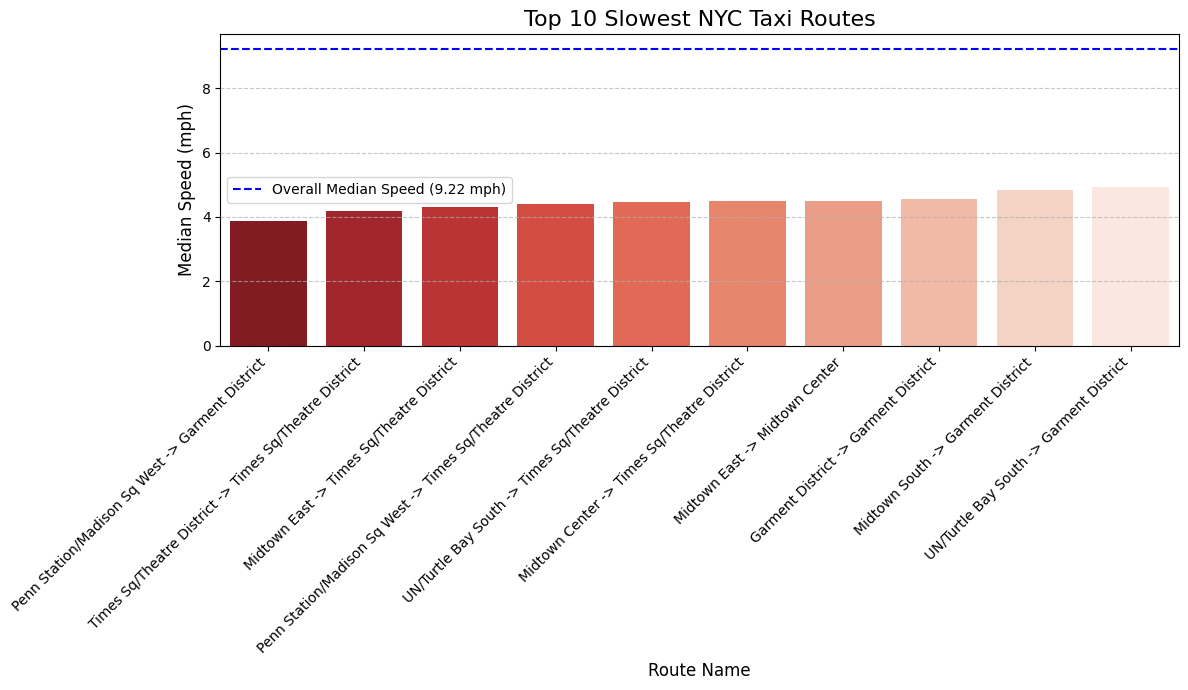

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by median_speed_mph in ascending order
slowest_10_plot_df = slowest_10_named.sort_values(by='median_speed_mph', ascending=True)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=slowest_10_plot_df,
    x='Route Name',
    y='median_speed_mph',
    hue='Route Name',
    palette='Reds_r',
    legend=False
)

# Add baselime for comparison
# Note: overall_median variable exists from previous cells
plt.axhline(overall_median, color='blue', linestyle='--', label=f'Overall Median Speed ({overall_median:.2f} mph)')

plt.xlabel('Route Name', fontsize=12)
plt.ylabel('Median Speed (mph)', fontsize=12)
plt.title('Top 10 Slowest NYC Taxi Routes', fontsize=16)

plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

These routes are extremely inefficient and it looks like most of these are from the "hotspot" of inefficient zones on the map earlier that were extremely close together. We quickly verify if this is true.

In [ ]:
slow_route_zones = set(slowest_10_named['PU_Zone']).union(set(slowest_10_named['DO_Zone']))
slow_overall_zones = set(inefficient_top10['Zone'])

intersection = slow_route_zones.intersection(slow_overall_zones)

print("Zones present in BOTH the slowest routes and the slowest overall zones:")
print(intersection)

print("\nTotal unique zones in top 10 slowest routes:", len(slow_route_zones))
print("Number of those that are in the 'Top 10 Inefficient Zones' list:", len(intersection))

comparison_df = pd.DataFrame({
    'Zone Name': list(slow_route_zones),
    'Is in Top 10 Inefficient Zones': [z in slow_overall_zones for z in slow_route_zones]
})
display(comparison_df)

Zones present in BOTH the slowest routes and the slowest overall zones:
{'Midtown South', 'Penn Station/Madison Sq West', 'Midtown East', 'Times Sq/Theatre District', 'Garment District', 'Midtown Center'}

Total unique zones in top 10 slowest routes: 7
Number of those that are in the 'Top 10 Inefficient Zones' list: 6


,Zone Name,Is in Top 10 Inefficient Zones
0,Midtown South,True
1,Penn Station/Madison Sq West,True
2,Midtown East,True
3,UN/Turtle Bay South,False
4,Times Sq/Theatre District,True
5,Garment District,True
6,Midtown Center,True


Out of the top 10 most inefficient routes, 5 out of 6 of the zone endpoints are in the hotspot of most inefficient routes, and the routes go between them. Hence these inefficient routes are actually short, and we return to the problem of optimizing shorter routes, like under 1 and 2 miles, which can be done using bikes & scooters.

# 9. Carpooling Simulation

If more people travel in one taxi, it is much more efficient and reduces congestion. We start by creating a bar graph of different passenger counts and their frequencies to see how we can optimize it.

In [ ]:
# Calculate frequency
passenger_counts = combined_df_sample['passenger_count'].value_counts().sort_index()

# Calculate percentage distribution
passenger_percentages = (passenger_counts / len(combined_df_sample)) * 100

# Combine
passenger_stats = pd.DataFrame({
    'Frequency': passenger_counts,
    'Percentage': passenger_percentages
})

print('Passenger Count Frequency and Percentage Distribution:')
print(passenger_stats)

Passenger Count Frequency and Percentage Distribution:
                 Frequency  Percentage
passenger_count                       
1.0                 278744   78.143248
2.0                  52418   14.694891
3.0                  12486    3.500332
4.0                   7800    2.186656
5.0                   3110    0.871859
6.0                   2148    0.602172
8.0                      3    0.000841


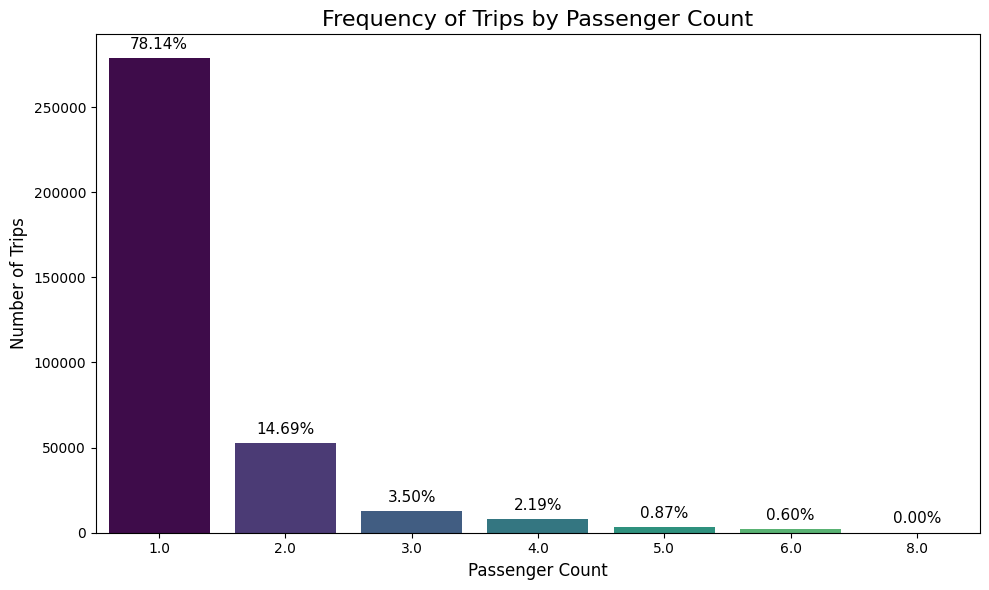

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

ax = sns.barplot(x=passenger_stats.index, y='Frequency', data=passenger_stats, hue=passenger_stats.index, palette='viridis', legend=False)

# Add title and labels
plt.title('Frequency of Trips by Passenger Count', fontsize=16)
plt.xlabel('Passenger Count', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)

# Add percentage valuesa above bars
for i, p in enumerate(ax.patches):
    percentage = passenger_stats['Percentage'].iloc[i]
    ax.annotate(f'{percentage:.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                fontsize=11, color='black', xytext=(0, 10),
                textcoords='offset points')

plt.tight_layout()
plt.show()

We see that most trips are only 1 passenger. However, having trips with multiple passengers would be extremely efficient. Hence we propose a system where riders put their pickup and dropoff location on an app and taxi drivers pick up multiple people whose pickup and dropoff locations are very close,  if they are in the same zone pickup & dropoff (that isn't one of the 10 least efficient). Also the time they ask for pickup/dropoff has to be within 10 minutes of each other. We count the percent of rides that can be optimized as such.

Total Original Trips: 356709
Potential Matches Found (10-min window): 3689
Optimized Trip Count: 353020
Percentage Reduction: 1.03%


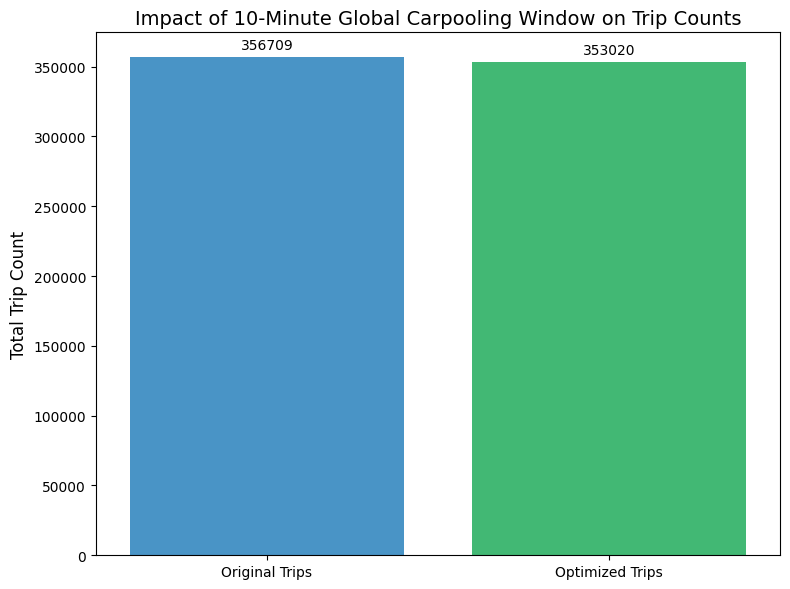

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

combined_df_sample = combined_df_sample.sort_values(by=['PULocationID', 'DOLocationID', 'tpep_pickup_datetime'])

# Calculate time difference between consecutive trips on the same route
same_route = (combined_df_sample['PULocationID'] == combined_df_sample['PULocationID'].shift(1)) & \
             (combined_df_sample['DOLocationID'] == combined_df_sample['DOLocationID'].shift(1))

time_diff = combined_df_sample['tpep_pickup_datetime'].diff()

# Identify potential matches within 10 minutes
potential_matches = (same_route) & (time_diff <= pd.Timedelta(minutes=10))
num_potential_matches = potential_matches.sum()

# Calculate Optimized Trip Count
original_count = len(combined_df_sample)
optimized_count = original_count - num_potential_matches

pct_reduction = (num_potential_matches / original_count) * 100
print(f"Total Original Trips: {original_count}")
print(f"Potential Matches Found (10-min window): {num_potential_matches}")
print(f"Optimized Trip Count: {optimized_count}")
print(f"Percentage Reduction: {pct_reduction:.2f}%")

plot_df = pd.DataFrame({
    'Category': ['Original Trips', 'Optimized Trips'],
    'Trip Count': [original_count, optimized_count]
})

plt.figure(figsize=(8, 6))

splot = sns.barplot(x='Category', y='Trip Count', data=plot_df, hue='Category', palette=['#3498db', '#2ecc71'], legend=False)

plt.title('Impact of 10-Minute Global Carpooling Window on Trip Counts', fontsize=14)
plt.ylabel('Total Trip Count', fontsize=12)
plt.xlabel('', fontsize=12)

# put labels on top of bars
for p in splot.patches:
    splot.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.tight_layout()
plt.show()

We see only a 1.03% reduction. However, this is not fully optimized, we can also pick people up in different zones if they are on the way.

In [ ]:
import pandas as pd
import numpy as np

# Define Long (> 5 miles) and Short (< 2 miles) trips
long_trips = combined_df_sample[combined_df_sample['trip_distance'] > 5].copy()
short_trips = combined_df_sample[combined_df_sample['trip_distance'] < 2].copy()

# Sort by pickup datetime for window comparisons
long_trips = long_trips.sort_values('tpep_pickup_datetime')
short_trips = short_trips.sort_values('tpep_pickup_datetime')

# Coordinate mapping using the zones_df and bottleneck_data available in context
default_lat, default_lon = 40.7580, -73.9855
zone_coords = pd.merge(zones_df, pd.DataFrame(bottleneck_data), on='Zone', how='left')
zone_coords['lat'] = zone_coords['lat'].fillna(default_lat)
zone_coords['lon'] = zone_coords['lon'].fillna(default_lon)
location_to_coords = zone_coords.set_index('LocationID')[['lat', 'lon']].to_dict('index')

def get_trip_coords(df):
    df['pu_lat'] = df['PULocationID'].map(lambda x: location_to_coords.get(x, {'lat': default_lat})['lat'])
    df['pu_lon'] = df['PULocationID'].map(lambda x: location_to_coords.get(x, {'lon': default_lon})['lon'])
    df['do_lat'] = df['DOLocationID'].map(lambda x: location_to_coords.get(x, {'lat': default_lat})['lat'])
    df['do_lon'] = df['DOLocationID'].map(lambda x: location_to_coords.get(x, {'lon': default_lon})['lon'])
    return df

long_trips = get_trip_coords(long_trips)
short_trips = get_trip_coords(short_trips)

on_the_way_matches = []
buffer = 0.005

for _, l_trip in long_trips.iterrows():
    # use window of up to 5 minutes for each
    window_start = l_trip['tpep_pickup_datetime'] - pd.Timedelta(minutes=5)
    window_end = l_trip['tpep_pickup_datetime'] + pd.Timedelta(minutes=5)

    # Filter short trips in window
    potential_shorts = short_trips[(short_trips['tpep_pickup_datetime'] >= window_start) &
                                   (short_trips['tpep_pickup_datetime'] <= window_end)]

    # Long trip bounding box
    # A box seems too large but NYC roads form a grid so a rectangle is effective
    # trips are based on manhattan distance
    min_lat = min(l_trip['pu_lat'], l_trip['do_lat']) - buffer
    max_lat = max(l_trip['pu_lat'], l_trip['do_lat']) + buffer
    min_lon = min(l_trip['pu_lon'], l_trip['do_lon']) - buffer
    max_lon = max(l_trip['pu_lon'], l_trip['do_lon']) + buffer

    for s_idx, s_trip in potential_shorts.iterrows():
        pu_inside = (min_lat <= s_trip['pu_lat'] <= max_lat) and (min_lon <= s_trip['pu_lon'] <= max_lon)
        do_inside = (min_lat <= s_trip['do_lat'] <= max_lat) and (min_lon <= s_trip['do_lon'] <= max_lon)

        if pu_inside and do_inside:
            on_the_way_matches.append({'long_trip_id': _, 'short_trip_id': s_idx})

matches_df = pd.DataFrame(on_the_way_matches)
print(f"Found {len(matches_df)} short trips that are 'on the way' of a long trip (Analyzed 5,000 long trips).")
print(matches_df.head())

Found 169305 short trips that are 'on the way' of a long trip (Analyzed 5,000 long trips).
   long_trip_id  short_trip_id
0            54             38
1            54             45
2            71             38
3            71             45
4            71             31


In [ ]:
import pandas as pd

# Identify unique short tripthat were found to be 'on the way'
unique_removable_short_trips = matches_df['short_trip_id'].nunique()

# Total unique short trips that could be removed
num_removable = unique_removable_short_trips

optimized_trip_count_otw = total_trips - num_removable

pct_reduction_otw = (num_removable / total_trips) * 100

print(f"Total Original Trips: {total_trips}")
print(f"Unique 'On-the-Way' Short Trips Consolidated (from 5,000 long trips): {num_removable}")
print(f"'On-the-Way' Optimized Trip Count: {optimized_trip_count_otw}")
print(f"Percentage Reduction (On-the-Way): {pct_reduction_otw:.2f}%")

Total Original Trips: 356709
Unique 'On-the-Way' Short Trips Consolidated (from 5,000 long trips): 89904
'On-the-Way' Optimized Trip Count: 266805
Percentage Reduction (On-the-Way): 25.20%


Now we see a extremely large optimization of 25%. Granted, many people prefer travelling by themselves and this bounding box model isn't perfect as it some non-grid areas it could lead to large detours. However, even if we assume half the people refuse to carpool and another chunk of them lead to too large of a detour, we still have a 10% reduction. With detailed NYC maps and real time traffic data, one could get an even more accurate picture of how effective this is. However, the potential is quite high.

# 10. Summary

This analysis of NYC taxi data revealed several actionable strategies to reduce traffic congestion.

**Key Findings:**

1.  **Inefficient Short Trips**: A significant portion of taxi trips (56.52% under 2 miles) are inefficient due to low average speeds (e.g., 7.85 mph for trips under 1 mile), which are comparable to bikes & scooters. These short trips are less common in warmer months due to better weather.

2.  **Peak Hour Congestion**: Median average speeds drop substantially during 10 AM - 6 PM, indicating peak congestion.

3.  **Congestion Hotspots**: Several Manhattan zones (e.g., Garment District, Midtown Center, Times Sq) are identified as persistent congestion bottlenecks, with very low median taxi speeds. Many of the slowest specific routes are within or between these central Manhattan zones.
4.  **Carpooling Potential**: A large majority of taxi trips (78%) carry only one passenger. While simple carpooling for same-route, same-time trips yielded minimal impact (0.52% reduction), a more advanced "on-the-way" model, matching short trips with long trips, demonstrated a substantial potential for a 25.20% reduction in total trips.

**Recommendations:**

1. **Incentivize scooter & bike travel:** Instead of inefficient, short trips, bikes & scooters provide a quick, energy efficient way to commute short distances.  This would especially optimize summer months when traffic is already at its lowest. In colder months, when people prefer taxis, it could still create a difference, though other methods may be preferred.
2. **Dynamic pricing:** A dynamic pricing model could encourage people to use other forms of transport during peak hours. We suggest a $10 surcharge for trips starting between 8am and 8pm. This is especially effective because it leads to a larger percieved increase in shorter, cheaper trips. A simulation at different price elasticities showed that it could reduce trips under 1 mile by up to 7% and overall trips by about 5%.
3. **Carpooling App:** Develop app-based carpooling that matches shorter rides along the routes of longer, journeys, without significant detours. Our simulation found that matching long & short rides together could lead to a 25% reduction in taxi trips, though it does assume all passengers are comfortable carpooling. It also assumes roads form grids, which isn't true in all scenarios. Overall, the simulation could be made more realistic by using real map data from NYC and route planning, but it shows the potential of carpooling.